In [14]:
import pandas as pd

customers = pd.read_csv(
    "../data/raw/customers.csv",
    parse_dates=["signup_date"],
)

In [2]:
customers.shape

(20000, 8)

In [1]:
import sys

print(sys.executable)

c:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI\.venv\Scripts\python.exe


In [2]:
import pandas
import numpy

print(pandas.__version__)
print(numpy.__version__)

3.0.5
2.5.2


In [4]:
customers["segment"].value_counts()

segment
SMB           10945
Mid-Market     6083
Enterprise     2972
Name: count, dtype: int64

In [5]:
customers.groupby("segment")["company_size"].agg(
    ["min", "median", "mean", "max"]
)

,min,median,mean,max
segment,,,,
Enterprise,2001,5015.0,6982.318641,50000
Mid-Market,251,1125.0,1129.074634,2000
SMB,10,131.0,130.182184,250


In [6]:
customers.describe()

,company_size,signup_date
count,20000.000000,20000
mean,1452.222800,2025-07-03 10:18:07.200000
min,10.000000,2024-01-01 00:00:00
25%,120.000000,2024-10-03 00:00:00
50%,230.000000,2025-07-03 00:00:00
75%,1419.000000,2026-03-30 00:00:00
max,50000.000000,2026-12-31 00:00:00
std,3388.720347,NaN


In [7]:
customers["industry"].value_counts()

industry
Logistics                2065
Technology               2039
Healthcare               2016
Telecommunications       2011
Education                2006
Manufacturing            1989
Financial Services       1987
Professional Services    1986
Government               1961
Retail                   1940
Name: count, dtype: int64

In [8]:
customers["region"].value_counts()

region
North America    6937
Europe           5065
APAC             4027
Latin America    2010
Middle East      1961
Name: count, dtype: int64

In [9]:
customers.isna().sum()

customer_id            0
industry               0
region                 0
segment                0
company_size           0
signup_date            0
account_manager_id     0
acquisition_channel    0
dtype: int64

In [10]:
customers["customer_id"].duplicated().sum()

np.int64(0)

In [2]:
import pandas as pd
contracts = pd.read_csv(
    "../data/raw/contracts.csv",
    parse_dates=[
        "start_date",
        "end_date",
        "renewal_date",
    ],
)

contracts.shape

(20000, 10)

In [3]:
contracts["contract_type"].value_counts(
    normalize=True
).round(3)

contract_type
Annual        0.649
Two-year      0.202
Three-year    0.149
Name: proportion, dtype: float64

In [5]:
contracts.head()

,contract_id,customer_id,start_date,end_date,renewal_date,annual_contract_value,total_contract_value,contract_type,auto_renew,contract_status
0,CT000001,C00001,2024-09-19,2026-09-19,2026-09-19,835747.92,1671495.84,Two-year,True,Active
1,CT000002,C00002,2025-05-22,2026-05-22,2026-05-22,386859.14,386859.14,Annual,True,Active
2,CT000003,C00003,2024-09-24,2027-09-24,2027-09-24,3393661.44,10180984.32,Three-year,True,Active
3,CT000004,C00004,2024-02-15,2026-02-14,2026-02-14,12524533.96,25049067.92,Two-year,False,Active
4,CT000005,C00005,2026-03-29,2027-03-29,2027-03-29,574056.25,574056.25,Annual,True,Active


In [ ]:
import pandas as pd

customers = pd.read_csv(
    "../data/raw/customers.csv",
    parse_dates=["signup_date"],
)

print(customers.shape)

(20000, 8)


In [ ]:
contracts = pd.read_csv(
    "../data/raw/contracts.csv",
    parse_dates=[
        "start_date",
        "end_date",
        "renewal_date",
    ],
)

print(contracts.shape)
print(contracts.columns.tolist())

(20000, 11)
['contract_id', 'customer_id', 'segment', 'start_date', 'end_date', 'renewal_date', 'annual_contract_value', 'total_contract_value', 'contract_type', 'auto_renew', 'contract_status']


In [5]:
pd.crosstab(
    contracts["segment"],
    contracts["contract_type"],
    normalize="index",
).round(3)

contract_type,Annual,Three-year,Two-year
segment,,,
Enterprise,0.000,1.0,0.000
Mid-Market,0.334,0.0,0.666
SMB,1.000,0.0,0.000


In [6]:
contracts.groupby("segment")[
    "annual_contract_value"
].agg(
    ["count", "min", "median", "mean", "max"]
).round(0)

,count,min,median,mean,max
segment,,,,,
Enterprise,2972,843972.0,14905218.0,22120582.0,593438052.0
Mid-Market,6083,241779.0,3025404.0,3862064.0,52465638.0
SMB,10945,31423.0,503100.0,622868.0,5045459.0


In [7]:
revenue_by_segment = (
    contracts
    .groupby("segment")["annual_contract_value"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_segment

segment
Enterprise    6.574237e+10
Mid-Market    2.349294e+10
SMB           6.817286e+09
Name: annual_contract_value, dtype: float64

In [8]:
(revenue_by_segment / revenue_by_segment.sum()).round(3)

segment
Enterprise    0.684
Mid-Market    0.245
SMB           0.071
Name: annual_contract_value, dtype: float64

In [9]:
contracts.nlargest(
    10,
    "annual_contract_value"
)[
    [
        "customer_id",
        "segment",
        "annual_contract_value",
        "contract_type",
    ]
]

,customer_id,segment,annual_contract_value,contract_type
19063,C19064,Enterprise,5.934381e+08,Three-year
13939,C13940,Enterprise,3.540113e+08,Three-year
7977,C07978,Enterprise,2.583624e+08,Three-year
4302,C04303,Enterprise,2.537632e+08,Three-year
5693,C05694,Enterprise,2.281555e+08,Three-year
8211,C08212,Enterprise,2.111193e+08,Three-year
1955,C01956,Enterprise,1.791500e+08,Three-year
5706,C05707,Enterprise,1.647323e+08,Three-year
4523,C04524,Enterprise,1.636568e+08,Three-year
1977,C01978,Enterprise,1.588169e+08,Three-year


In [10]:
contracts.groupby("segment")[
    "auto_renew"
].mean().round(3)

segment
Enterprise    0.852
Mid-Market    0.780
SMB           0.695
Name: auto_renew, dtype: float64

In [13]:
pd.crosstab(
    contracts["segment"],
    contracts["contract_type"],
    normalize="index",
).round(3)

contract_type,Annual,Three-year,Two-year
segment,,,
Enterprise,0.487,0.205,0.308
Mid-Market,0.647,0.098,0.254
SMB,0.754,0.050,0.195


In [14]:
contracts.groupby("segment")[
    "annual_contract_value"
].agg(
    ["count", "min", "median", "mean", "max"]
).round(0)

,count,min,median,mean,max
segment,,,,,
Enterprise,2972,7500000.0,14927466.0,19001310.0,100000000.0
Mid-Market,6083,1000000.0,3025404.0,3710228.0,10000000.0
SMB,10945,200000.0,503100.0,600900.0,1500000.0


In [15]:
revenue_by_segment = (
    contracts
    .groupby("segment")["annual_contract_value"]
    .sum()
    .sort_values(ascending=False)
)

(revenue_by_segment / revenue_by_segment.sum()).round(3)

segment
Enterprise    0.660
Mid-Market    0.264
SMB           0.077
Name: annual_contract_value, dtype: float64

In [19]:
subscriptions = pd.read_csv(
    "../data/raw/subscriptions.csv")

In [19]:
subscriptions.shape

(49259, 8)

In [20]:
products_per_customer = (
    subscriptions
    .groupby("customer_id")["product_id"]
    .nunique()
)

products_per_customer.describe()

count    20000.000000
mean         2.462950
std          1.092377
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: product_id, dtype: float64

In [21]:
subscription_segments = subscriptions.merge(
    customers[
        [
            "customer_id",
            "segment",
        ]
    ],
    on="customer_id",
    how="left",
)

In [22]:
subscription_segments.groupby(
    "segment"
)["product_id"].nunique()

segment
Enterprise    5
Mid-Market    5
SMB           5
Name: product_id, dtype: int64

In [23]:
customer_product_counts = (
    subscription_segments
    .groupby(
        ["customer_id", "segment"]
    )["product_id"]
    .nunique()
    .reset_index(name="product_count")
)

In [24]:
customer_product_counts.groupby(
    "segment"
)["product_count"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
segment,,,,,
Enterprise,2972,3.66,4.0,1,5
Mid-Market,6083,2.79,3.0,1,5
SMB,10945,1.96,2.0,1,5


In [25]:
subscription_acv = (
    subscriptions
    .groupby("customer_id")["annual_value"]
    .sum()
    .rename("subscription_acv")
)

In [28]:
financial_check = contracts[
    [
        "customer_id",
        "annual_contract_value",
    ]
].merge(
    subscription_acv,
    on="customer_id",
    how="left",
)

In [29]:
financial_check["difference"] = (
    financial_check["annual_contract_value"]
    - financial_check["subscription_acv"]
)

financial_check["difference"].abs().max()

np.float64(0.020000003278255463)

In [30]:
product_penetration = (
    subscriptions
    .groupby("product_id")["customer_id"]
    .nunique()
    / customers["customer_id"].nunique()
)

product_penetration.sort_values(
    ascending=False
).round(3)

product_id
P001    1.000
P002    0.470
P003    0.391
P004    0.330
P005    0.273
Name: customer_id, dtype: float64

In [37]:
subscription_acv = (
    subscriptions
    .groupby("customer_id")["annual_value"]
    .sum()
    .rename("subscription_acv")
)

financial_check = contracts[
    [
        "customer_id",
        "annual_contract_value",
    ]
].merge(
    subscription_acv,
    on="customer_id",
    how="left",
)

financial_check["difference"] = (
    financial_check["annual_contract_value"]
    - financial_check["subscription_acv"]
)

print(
    financial_check["difference"].abs().max()
)

1.4901161193847656e-08


In [38]:
worst = financial_check.loc[
    financial_check["difference"].abs().idxmax()
]

worst

customer_id                   C04524
annual_contract_value    93268662.79
subscription_acv         93268662.79
difference                       0.0
Name: 4523, dtype: object

In [39]:
subscriptions[
    subscriptions["customer_id"] == worst["customer_id"]
][
    [
        "customer_id",
        "product_id",
        "annual_value",
    ]
]

,customer_id,product_id,annual_value
11118,C04524,P001,19910780.72
11119,C04524,P002,20676262.04
11120,C04524,P003,21357679.79
11121,C04524,P004,15148289.33
11122,C04524,P005,16175650.91


In [40]:
financial_check["difference"].abs().max() < 0.01

np.True_

In [41]:
import numpy as np

np.isclose(
    financial_check["annual_contract_value"],
    financial_check["subscription_acv"],
    atol=0.01
).all()

np.True_

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

In [51]:
from src.customer_state import generate_customer_state

In [15]:
test_customers = customers.head(100).copy()

In [53]:
state_test = generate_customer_state(
    customers=test_customers,
    start_date="2026-01-05",
    end_date="2026-03-23",
    seed=42,
)

In [54]:
state_test.shape

(1200, 7)

In [55]:
state_test["health_score"].describe()

count    1200.000000
mean       73.947108
std         8.533960
min        44.440000
25%        68.645000
50%        74.535000
75%        80.027500
max       100.000000
Name: health_score, dtype: float64

In [56]:
state_test["behaviour"].value_counts(
    normalize=True
).round(3)

behaviour
Stable               0.58
Declining            0.22
Improving            0.15
Rapidly Declining    0.05
Name: proportion, dtype: float64

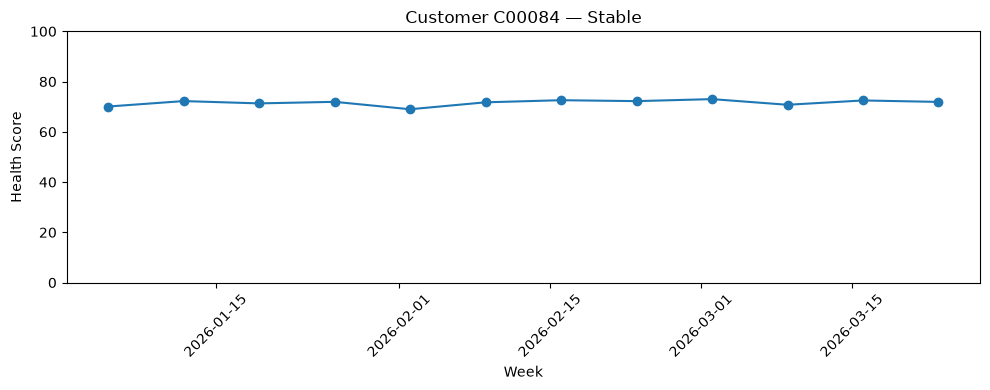

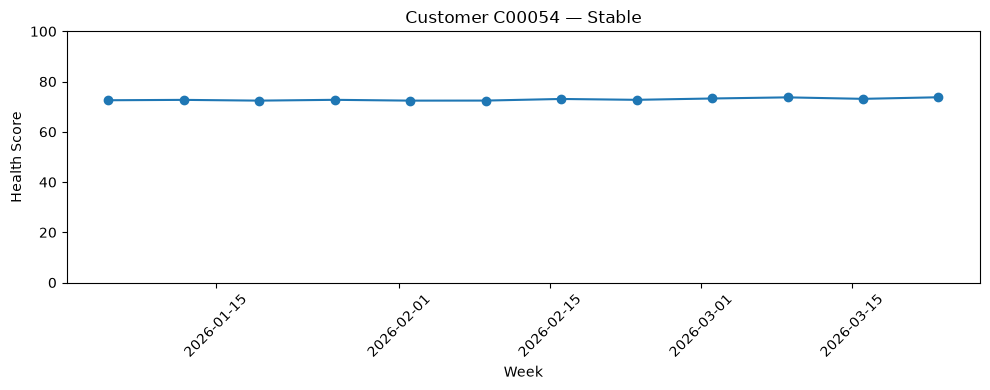

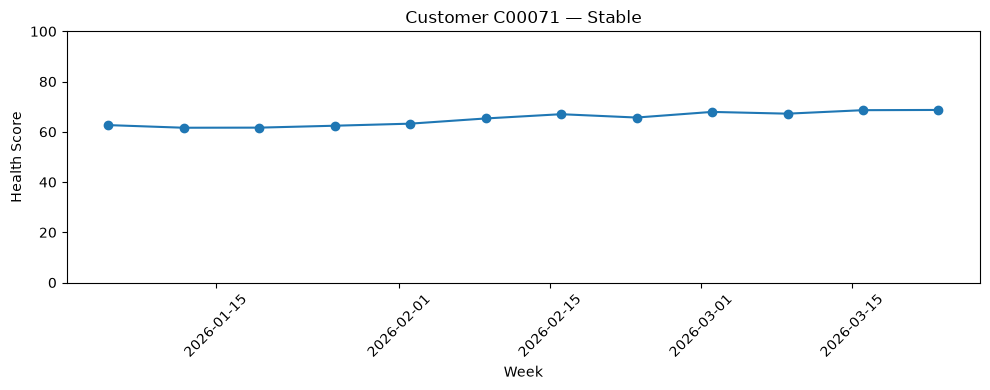

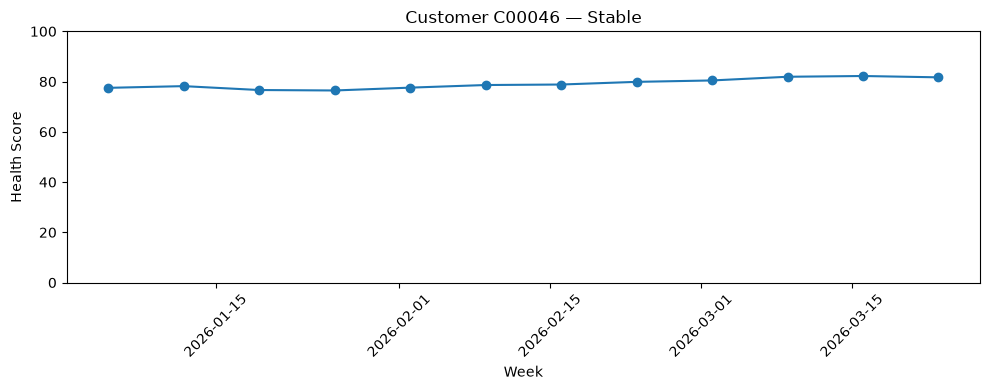

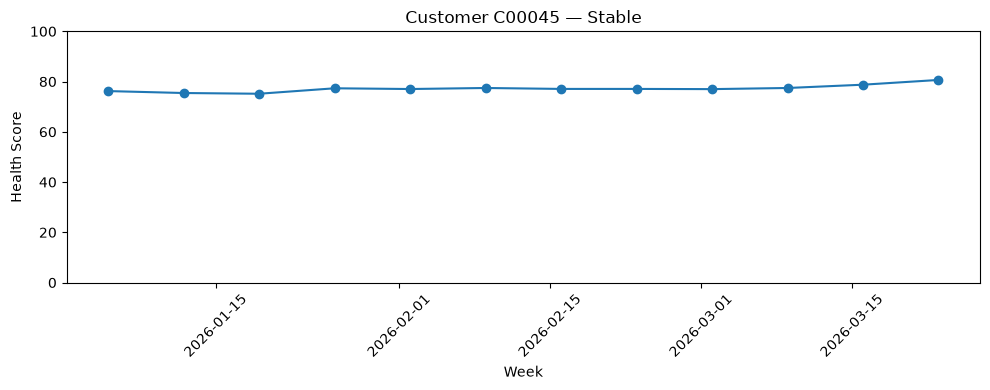

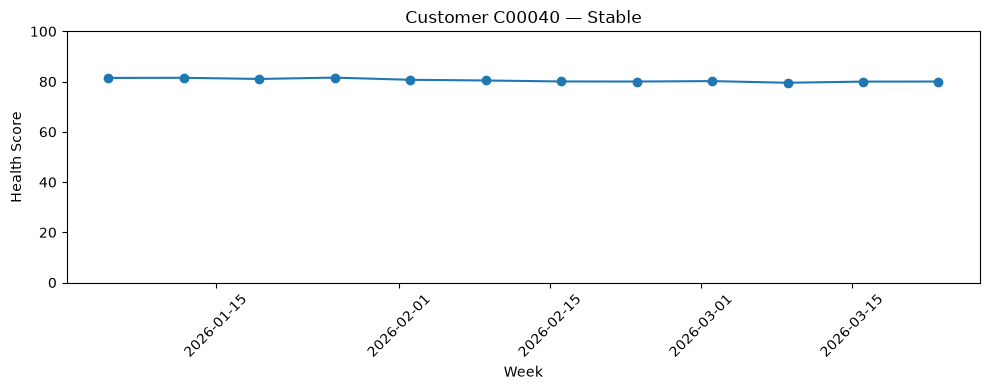

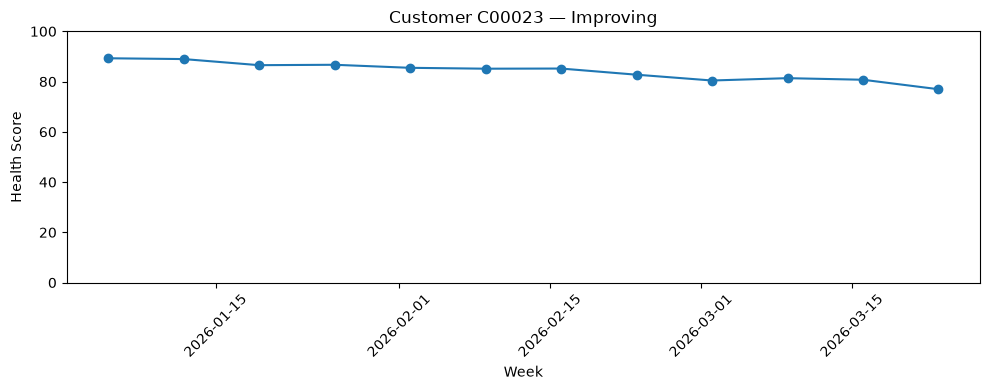

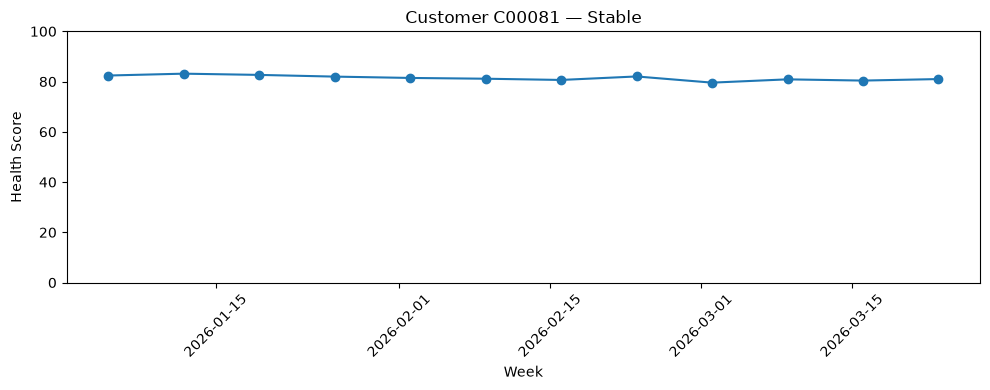

In [ ]:
import matplotlib.pyplot as plt

sample_customers = (
    state_test["customer_id"]
    .drop_duplicates()
    .sample(
        8,
        random_state=42,
    )
)

for customer_id in sample_customers:

    customer_data = state_test[
        state_test["customer_id"]
        == customer_id
    ]

    plt.figure(figsize=(10, 4))

    plt.plot(
        customer_data["week_start"],
        customer_data["health_score"],
        marker="o",
    )

    plt.title(
        f"Customer {customer_id} — "
        f"{customer_data['behaviour'].iloc[0]}"
    )

    plt.xlabel("Week")
    plt.ylabel("Health Score")

    plt.ylim(0, 100)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

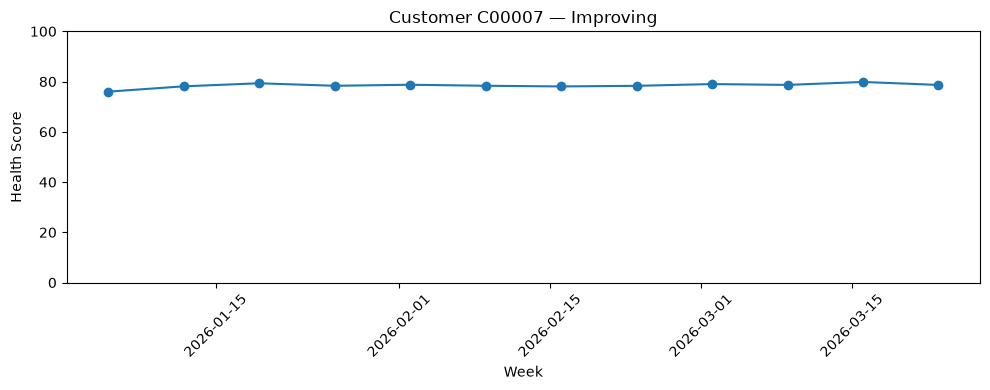

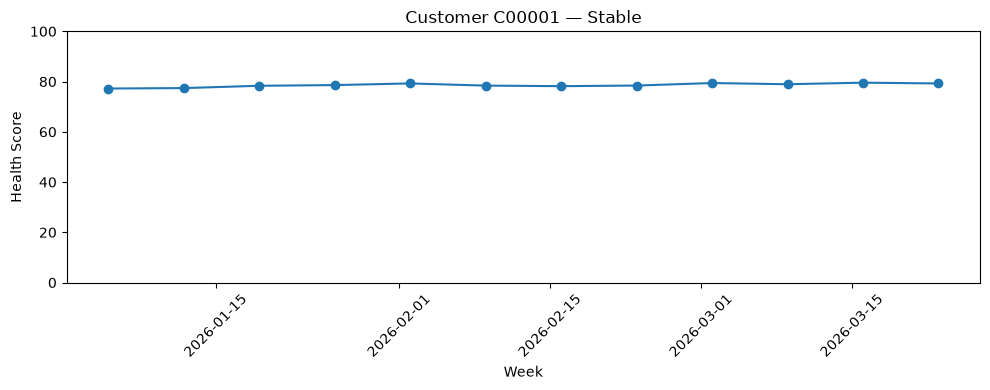

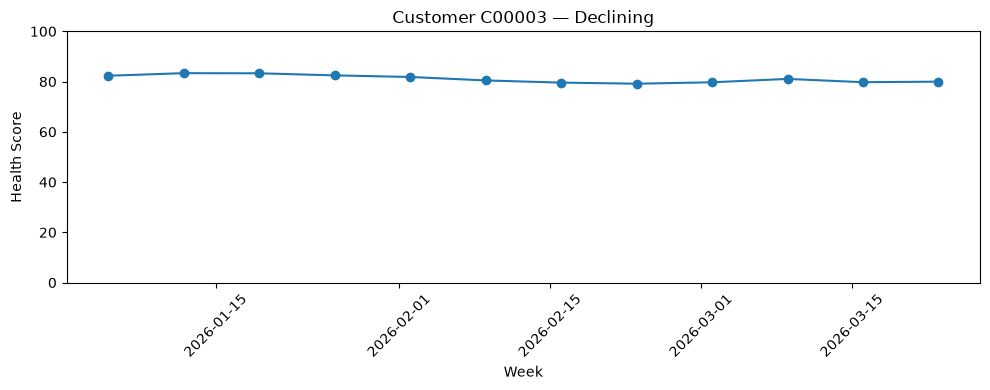

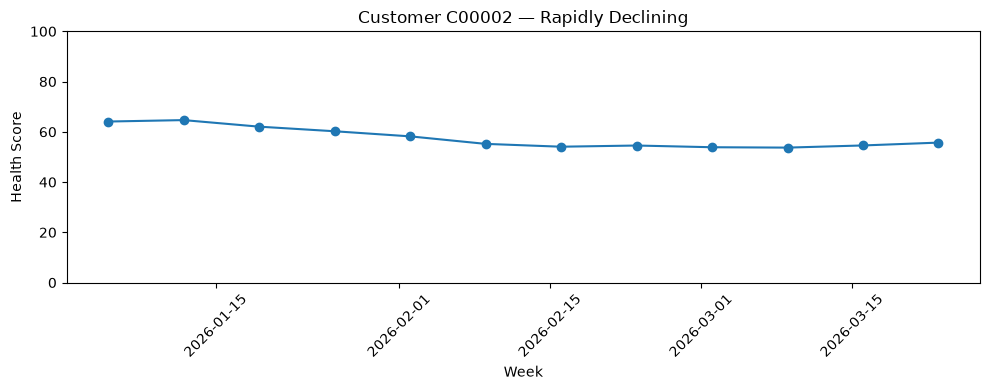

In [57]:
for behaviour in [
    "Improving",
    "Stable",
    "Declining",
    "Rapidly Declining",
]:

    customer_id = (
        state_test[
            state_test["behaviour"] == behaviour
        ]["customer_id"]
        .iloc[0]
    )

    customer_data = state_test[
        state_test["customer_id"] == customer_id
    ]

    plt.figure(figsize=(10, 4))

    plt.plot(
        customer_data["week_start"],
        customer_data["health_score"],
        marker="o",
    )

    plt.title(
        f"Customer {customer_id} — {behaviour}"
    )

    plt.xlabel("Week")
    plt.ylabel("Health Score")
    plt.ylim(0, 100)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [58]:
from src.usage import generate_usage

In [59]:
test_customers = customers.head(100).copy()

In [20]:
test_subscriptions = subscriptions[
    subscriptions["customer_id"].isin(
        test_customers["customer_id"]
    )
].copy()

In [61]:
test_state = generate_customer_state(
    customers=test_customers,
    start_date="2026-01-05",
    end_date="2026-03-23",
    seed=42,
)

In [62]:
test_usage = generate_usage(
    customers=test_customers,
    subscriptions=test_subscriptions,
    customer_state=test_state,
    seed=42,
)

In [63]:
test_usage.shape

(1200, 12)

In [64]:
test_usage.head()

,customer_id,week_start,active_users,sessions,active_days,usage_minutes,features_used,p001_sessions,p002_sessions,p003_sessions,p004_sessions,p005_sessions
0,C00001,2026-01-05,103,553,3,11923,2,335,0,218,0,0
1,C00001,2026-01-12,103,519,7,10615,2,347,0,172,0,0
2,C00001,2026-01-19,108,540,5,9574,2,360,0,180,0,0
3,C00001,2026-01-26,118,645,6,10588,2,409,0,236,0,0
4,C00001,2026-02-02,107,573,5,10944,2,393,0,180,0,0


In [65]:
test_usage[
    [
        "active_users",
        "sessions",
        "active_days",
        "usage_minutes",
        "features_used",
    ]
].describe()

,active_users,sessions,active_days,usage_minutes,features_used
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,102.575000,659.756667,2.718333,12904.005833,1.167500
std,288.234914,1951.508038,3.044951,39041.921364,1.476909
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,53.000000,351.000000,6.000000,6586.250000,2.000000
max,2038.000000,14342.000000,7.000000,273430.000000,5.000000


In [66]:
(test_usage["active_users"] >= 0).all()

np.True_

In [67]:
(test_usage["sessions"] >= 0).all()

np.True_

In [68]:
test_usage["active_days"].between(0, 7).all()

np.True_

In [69]:
(test_usage["usage_minutes"] >= 0).all()

np.True_

In [70]:
test_usage["features_used"].between(
    0, 5
).all()

np.True_

In [73]:
test_usage_long = test_usage.melt(
    id_vars=[
        "customer_id",
        "week_start",
    ],
    value_vars=[
        "p001_sessions",
        "p002_sessions",
        "p003_sessions",
        "p004_sessions",
        "p005_sessions",
    ],
    var_name="product",
    value_name="product_sessions",
)

In [74]:
test_usage_long.groupby(
    "product"
)["product_sessions"].agg(
    ["count", "mean", "max"]
)

,count,mean,max
product,,,
p001_sessions,1200,350.605000,7161
p002_sessions,1200,123.159167,3524
p003_sessions,1200,117.996667,3657
p004_sessions,1200,28.534167,869
p005_sessions,1200,39.461667,1610


In [75]:
customer_id = test_customers["customer_id"].iloc[0]

print(
    test_subscriptions[
        test_subscriptions["customer_id"]
        == customer_id
    ]["product_id"].tolist()
)

['P001', 'P003']


In [76]:
test_usage[
    test_usage["customer_id"] == customer_id
][
    [
        "p001_sessions",
        "p002_sessions",
        "p003_sessions",
        "p004_sessions",
        "p005_sessions",
    ]
].head(12)

,p001_sessions,p002_sessions,p003_sessions,p004_sessions,p005_sessions
0,335,0,218,0,0
1,347,0,172,0,0
2,360,0,180,0,0
3,409,0,236,0,0
4,393,0,180,0,0
5,445,0,211,0,0
6,331,0,175,0,0
7,329,0,222,0,0
8,351,0,205,0,0
9,341,0,163,0,0


In [77]:
health_usage = test_usage.merge(
    test_state[
        [
            "customer_id",
            "week_start",
            "health_score",
        ]
    ],
    on=[
        "customer_id",
        "week_start",
    ],
    how="left",
)

In [78]:
health_usage[
    [
        "health_score",
        "active_users",
        "sessions",
        "usage_minutes",
    ]
].corr().round(2)

,health_score,active_users,sessions,usage_minutes
health_score,1.00,0.04,0.05,0.04
active_users,0.04,1.00,0.96,0.95
sessions,0.05,0.96,1.00,1.00
usage_minutes,0.04,0.95,1.00,1.00


In [79]:
test_state["week_start"].min(), test_state["week_start"].max()

(Timestamp('2026-01-05 00:00:00'), Timestamp('2026-03-23 00:00:00'))

In [80]:
test_usage[
    "active_users"
].eq(0).mean()

np.float64(0.54)

In [81]:
test_state.merge(
    test_usage[
        [
            "customer_id",
            "week_start",
            "active_users",
        ]
    ],
    on=["customer_id", "week_start"],
).groupby(
    "week_start"
)["active_users"].apply(
    lambda x: (x == 0).mean()
)

week_start
2026-01-05    0.55
2026-01-12    0.55
2026-01-19    0.54
2026-01-26    0.54
2026-02-02    0.55
2026-02-09    0.54
2026-02-16    0.54
2026-02-23    0.54
2026-03-02    0.54
2026-03-09    0.54
2026-03-16    0.53
2026-03-23    0.52
Name: active_users, dtype: float64

In [82]:
active_usage = test_usage[
    test_usage["active_users"] > 0
].copy()

In [86]:
active_usage[
    [
        "active_users",
        "sessions",
        "active_days",
        "usage_minutes",
        "features_used",
    ]
].describe().round(2)

,active_users,sessions,active_days,usage_minutes,features_used
count,552.00,552.00,552.00,552.00,552.00
mean,222.99,1434.25,5.91,28052.19,2.54
std,392.28,2678.50,1.13,53769.61,1.12
min,1.00,0.00,1.00,0.00,0.00
25%,25.00,113.00,5.00,2205.50,2.00
50%,80.00,428.50,6.00,7901.00,2.00
75%,209.25,1124.25,7.00,22184.50,3.00
max,2038.00,14342.00,7.00,273430.00,5.00


In [84]:
health_usage = test_usage.merge(
    test_state[
        [
            "customer_id",
            "week_start",
            "health_score",
        ]
    ],
    on=[
        "customer_id",
        "week_start",
    ],
    how="left",
)

In [85]:
health_usage = health_usage.sort_values(
    ["customer_id", "week_start"]
)

health_usage["health_change"] = (
    health_usage
    .groupby("customer_id")["health_score"]
    .diff()
)

health_usage["usage_change"] = (
    health_usage
    .groupby("customer_id")["active_users"]
    .diff()
)

In [87]:
health_usage[
    [
        "health_change",
        "usage_change",
    ]
].corr().round(2)

,health_change,usage_change
health_change,1.00,0.03
usage_change,0.03,1.00


In [97]:
test_usage = generate_usage(
    customers=test_customers,
    subscriptions=test_subscriptions,
    customer_state=test_state,
    seed=42,
)

In [98]:
health_usage = test_usage.merge(
    test_state[
        [
            "customer_id",
            "week_start",
            "health_score",
        ]
    ],
    on=[
        "customer_id",
        "week_start",
    ],
    how="left",
)

In [99]:
health_usage["health_change"] = (
    health_usage
    .groupby("customer_id")["health_score"]
    .diff()
)

health_usage["usage_change"] = (
    health_usage
    .groupby("customer_id")["active_users"]
    .diff()
)

In [100]:
health_usage["customer_avg_usage"] = (
    health_usage
    .groupby("customer_id")["active_users"]
    .transform("mean")
)

health_usage["relative_usage"] = (
    health_usage["active_users"]
    / health_usage["customer_avg_usage"]
)

In [101]:
health_usage[
    [
        "health_score",
        "relative_usage",
    ]
].corr().round(2)

,health_score,relative_usage
health_score,1.0,-0.0
relative_usage,-0.0,1.0


In [102]:
customer_level = (
    health_usage
    .groupby("customer_id")
    .agg(
        avg_health=("health_score", "mean"),
        avg_relative_usage=("relative_usage", "mean"),
    )
)

customer_level.corr().round(2)

,avg_health,avg_relative_usage
avg_health,1.00,0.09
avg_relative_usage,0.09,1.00


In [105]:

from scipy.stats import linregress

In [106]:
def calculate_slope(group, column):

    x = np.arange(len(group))
    y = group[column].values

    return linregress(x, y).slope

In [107]:
trend_test = (
    health_usage
    .groupby("customer_id")
    .apply(
        lambda g: pd.Series({
            "health_slope": calculate_slope(
                g,
                "health_score",
            ),
            "usage_slope": calculate_slope(
                g,
                "active_users",
            ),
        }),
        include_groups=False,
    )
)

In [108]:
trend_test.corr().round(2)

,health_slope,usage_slope
health_slope,1.00,0.15
usage_slope,0.15,1.00


In [ ]:
test_usage = generate_usage(
    customers=test_customers,
    subscriptions=test_subscriptions,
    customer_state=test_state,
    seed=42,
)

In [116]:
health_usage = test_usage.merge(
    test_state[
        [
            "customer_id",
            "week_start",
            "health_score",
            "behaviour",
        ]
    ],
    on=[
        "customer_id",
        "week_start",
    ],
    how="left",
)

health_usage = health_usage.sort_values(
    ["customer_id", "week_start"]
).reset_index(drop=True)

In [111]:
health_usage["health_change"] = (
    health_usage
    .groupby("customer_id")["health_score"]
    .diff()
)

health_usage["usage_change"] = (
    health_usage
    .groupby("customer_id")["active_users"]
    .diff()
)

In [30]:
import numpy as np
from scipy.stats import linregress


def calculate_slope(group, column):
    x = np.arange(len(group))
    y = group[column].values

    return linregress(x, y).slope

In [119]:
trend_test = (
    health_usage
    .groupby("customer_id")
    .apply(
        lambda g: pd.Series({
            "health_slope": calculate_slope(
                g,
                "health_score",
            ),
            "usage_slope": calculate_slope(
                g,
                "active_users",
            ),
            "behaviour": g["behaviour"].iloc[0],
        })
    )
    .reset_index()
)

In [120]:
trend_test.groupby(
    "behaviour"
)[
    [
        "health_slope",
        "usage_slope",
    ]
].mean().round(3)

,health_slope,usage_slope
behaviour,,
Declining,-0.215,1.373
Improving,0.217,-0.692
Rapidly Declining,-1.084,-0.534
Stable,-0.058,1.148


In [121]:
health_usage["health_change"] = (
    health_usage
    .groupby("customer_id")["health_score"]
    .diff()
)

health_usage["usage_change"] = (
    health_usage
    .groupby("customer_id")["active_users"]
    .diff()
)

In [122]:
health_usage[
    [
        "health_change",
        "usage_change",
    ]
].corr().round(2)

,health_change,usage_change
health_change,1.00,0.03
usage_change,0.03,1.00


In [123]:
trend_test = (
    health_usage
    .groupby(
        ["customer_id"]
    )
    .apply(
        lambda g: pd.Series({
            "health_slope": calculate_slope(
                g,
                "health_score",
            ),
            "usage_slope": calculate_slope(
                g,
                "active_users",
            ),
            "behaviour": g["behaviour"].iloc[0],
        }),
        include_groups=False,
    )
)

In [124]:
trend_test.groupby(
    "behaviour"
)[
    [
        "health_slope",
        "usage_slope",
    ]
].mean().round(3)

,health_slope,usage_slope
behaviour,,
Declining,-0.215,1.373
Improving,0.217,-0.692
Rapidly Declining,-1.084,-0.534
Stable,-0.058,1.148


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

In [10]:
from src.usage import generate_usage
from src.customer_state import generate_customer_state

In [16]:
test_state = generate_customer_state(
    customers=test_customers,
    start_date="2026-01-05",
    end_date="2026-06-22",
    seed=42,
)

In [21]:
test_usage = generate_usage(
    customers=test_customers,
    subscriptions=test_subscriptions,
    customer_state=test_state,
    seed=42,
)

In [23]:
test_usage.shape

(2500, 12)

In [24]:
test_usage[
    [
        "active_users",
        "sessions",
        "active_days",
        "usage_minutes",
        "features_used",
    ]
].describe().round(2)

,active_users,sessions,active_days,usage_minutes,features_used
count,2500.00,2500.00,2500.00,2500.00,2500.00
mean,108.81,712.58,2.82,13932.82,1.20
std,302.10,2112.30,3.05,42125.57,1.47
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00
75%,65.00,360.75,6.00,6782.25,2.00
max,2449.00,17279.00,7.00,342904.00,5.00


In [25]:
health_usage = test_usage.merge(
    test_state[
        [
            "customer_id",
            "week_start",
            "health_score",
            "behaviour",
        ]
    ],
    on=[
        "customer_id",
        "week_start",
    ],
    how="left",
).sort_values(
    [
        "customer_id",
        "week_start",
    ]
).reset_index(drop=True)

In [29]:
health_usage["health_change"] = (
    health_usage
    .groupby("customer_id")["health_score"]
    .diff()
)

health_usage["usage_change"] = (
    health_usage
    .groupby("customer_id")["active_users"]
    .diff()
)

health_usage

,customer_id,week_start,active_users,sessions,active_days,usage_minutes,features_used,p001_sessions,p002_sessions,p003_sessions,p004_sessions,p005_sessions,health_score,behaviour,health_change,usage_change
0,C00001,2026-01-05,123,580,7,12383,2,381,0,199,0,0,77.53,Stable,NaN,NaN
1,C00001,2026-01-12,123,613,7,11416,2,414,0,199,0,0,77.64,Stable,0.11,0.0
2,C00001,2026-01-19,125,621,7,11400,2,375,0,246,0,0,78.23,Stable,0.59,2.0
3,C00001,2026-01-26,130,669,7,12006,2,443,0,226,0,0,78.41,Stable,0.18,5.0
4,C00001,2026-02-02,130,719,6,15903,2,479,0,240,0,0,78.82,Stable,0.41,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,C00100,2026-05-25,209,1081,5,19535,3,595,309,0,0,177,47.60,Rapidly Declining,-0.93,-11.0
2496,C00100,2026-06-01,203,1123,6,21110,3,649,311,0,0,163,46.09,Rapidly Declining,-1.51,-6.0
2497,C00100,2026-06-08,187,1020,6,18883,3,561,299,0,0,160,46.07,Rapidly Declining,-0.02,-16.0
2498,C00100,2026-06-15,193,919,6,17412,3,501,271,0,0,147,45.42,Rapidly Declining,-0.65,6.0


In [31]:
trend_test = (
    health_usage
    .groupby("customer_id")
    .apply(
        lambda g: pd.Series({
            "health_slope": calculate_slope(
                g,
                "health_score",
            ),
            "usage_slope": calculate_slope(
                g,
                "active_users",
            ),
            "behaviour": g["behaviour"].iloc[0],
        })
    )
    .reset_index()
)

In [32]:
trend_test.groupby(
    "behaviour"
)[
    [
        "health_slope",
        "usage_slope",
    ]
].mean().round(3)

,health_slope,usage_slope
behaviour,,
Declining,-0.273,-0.909
Improving,0.253,-0.213
Rapidly Declining,-0.499,-1.618
Stable,-0.024,-0.012


In [33]:
test_usage.loc[
    test_usage["active_users"] > 0,
    [
        "active_users",
        "sessions",
        "active_days",
        "usage_minutes",
        "features_used",
    ]
].describe().round(2)

,active_users,sessions,active_days,usage_minutes,features_used
count,1199.00,1199.00,1199.00,1199.00,1199.00
mean,226.87,1485.78,5.87,29050.91,2.50
std,404.44,2856.12,1.20,57115.13,1.13
min,1.00,0.00,0.00,0.00,0.00
25%,25.00,115.00,5.00,2207.50,2.00
50%,76.00,394.00,6.00,7183.00,2.00
75%,200.00,1215.50,7.00,23273.50,3.00
max,2449.00,17279.00,7.00,342904.00,5.00


In [34]:
test_usage["active_users"].eq(0).mean()

np.float64(0.5204)

In [35]:
test_usage.groupby(
    "week_start"
)["active_users"].apply(
    lambda x: (x > 0).mean()
).round(3)

week_start
2026-01-05    0.45
2026-01-12    0.45
2026-01-19    0.46
2026-01-26    0.46
2026-02-02    0.45
2026-02-09    0.46
2026-02-16    0.46
2026-02-23    0.46
2026-03-02    0.46
2026-03-09    0.46
2026-03-16    0.47
2026-03-23    0.48
2026-03-30    0.49
2026-04-06    0.49
2026-04-13    0.50
2026-04-20    0.50
2026-04-27    0.51
2026-05-04    0.51
2026-05-11    0.51
2026-05-18    0.49
2026-05-25    0.49
2026-06-01    0.49
2026-06-08    0.50
2026-06-15    0.50
2026-06-22    0.49
Name: active_users, dtype: float64